### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [2]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics

# HELP US SPLIT OUR DATA INTO TESTING A TRAINING
from sklearn.model_selection import train_test_split

# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot

#import CTPLIB as ctp


# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [7]:
# READ IN THE DATA USING PANDAS 
df = pd.read_csv(r'C:\Users\Mohammed Al-Muqsit\Desktop\Repo\ctpWeek1\ds-fall-2025-tue\Week-08-Regression\data\NBA_train.csv')


# DISPLAY THE FIRST 5 ROWS
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [9]:
# Inspect our data using `df.describe()` function.
df.describe()


,SeasonEnd,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,1996.319760,0.574850,41.000000,8370.239521,8370.239521,3200.367665,6873.318563,2881.324551,5956.444311,319.043114,916.874251,1650.461078,2189.953293,1061.584431,2427.354491,1912.112575,668.364072,419.805988,1302.837126
std,9.243808,0.494662,12.740822,581.040114,587.543959,287.181266,401.027166,446.097941,830.596327,199.698941,523.982964,197.651728,244.491086,150.224519,130.671523,221.610925,93.393044,82.274913,153.973470
min,1980.000000,0.000000,11.000000,6901.000000,6909.000000,2565.000000,5972.000000,1981.000000,4153.000000,10.000000,75.000000,1189.000000,1475.000000,639.000000,2044.000000,1423.000000,455.000000,204.000000,931.000000
25%,1989.000000,0.000000,31.000000,7934.000000,7934.000000,2974.000000,6563.500000,2510.000000,5269.000000,131.500000,413.000000,1502.500000,2008.000000,953.500000,2346.500000,1735.000000,599.000000,359.000000,1192.000000
50%,1996.000000,1.000000,42.000000,8312.000000,8365.000000,3150.000000,6831.000000,2718.000000,5706.000000,329.000000,942.000000,1628.000000,2176.000000,1055.000000,2433.000000,1899.000000,658.000000,410.000000,1289.000000
75%,2005.000000,1.000000,50.500000,8784.500000,8768.500000,3434.500000,7157.000000,3296.000000,6753.500000,481.500000,1347.500000,1781.000000,2352.000000,1167.000000,2516.500000,2077.500000,729.000000,469.500000,1395.500000
max,2011.000000,1.000000,72.000000,10371.000000,10723.000000,3980.000000,8868.000000,3954.000000,7873.000000,841.000000,2284.000000,2388.000000,3051.000000,1520.000000,2753.000000,2575.000000,1053.000000,716.000000,1873.000000


#### Check for Nulls.

In [10]:
# Check for Nulls.
df.isnull().sum()


SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64

#### Check for Duplicates

In [14]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [23]:
def inspect_dataframe(input_df):
    print("Shape of the DataFrame:")
    print(input_df.shape)

    print('#' * 80)
    print("First 5 rows of the DataFrame:")
    print(input_df.head())

    print("#" * 80)
    print("Statistical Summary of the DataFrame:")
    print(input_df.describe())

    print("#" * 80)
    print("Count of Null Values in Each Column:")
    print(input_df.isnull().sum())

    print("#" * 80)
    print("Count of Duplicate Rows in the DataFrame:")
    print(input_df.duplicated().sum())

    return None

inspect_dataframe(df)




Shape of the DataFrame:
(835, 20)
################################################################################
First 5 rows of the DataFrame:
   SeasonEnd                 Team  Playoffs   W   PTS  oppPTS    FG   FGA  \
0       1980        Atlanta Hawks         1  50  8573    8334  3261  7027   
1       1980       Boston Celtics         1  61  9303    8664  3617  7387   
2       1980        Chicago Bulls         0  30  8813    9035  3362  6943   
3       1980  Cleveland Cavaliers         0  37  9360    9332  3811  8041   
4       1980       Denver Nuggets         0  30  8878    9240  3462  7470   

     2P   2PA   3P  3PA    FT   FTA   ORB   DRB   AST  STL  BLK   TOV  
0  3248  6952   13   75  2038  2645  1369  2406  1913  782  539  1495  
1  3455  6965  162  422  1907  2449  1227  2457  2198  809  308  1539  
2  3292  6668   70  275  2019  2592  1115  2465  2152  704  392  1684  
3  3775  7854   36  187  1702  2205  1307  2381  2108  764  342  1370  
4  3379  7215   83  255  1871  

#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

<Axes: xlabel='W', ylabel='Team'>

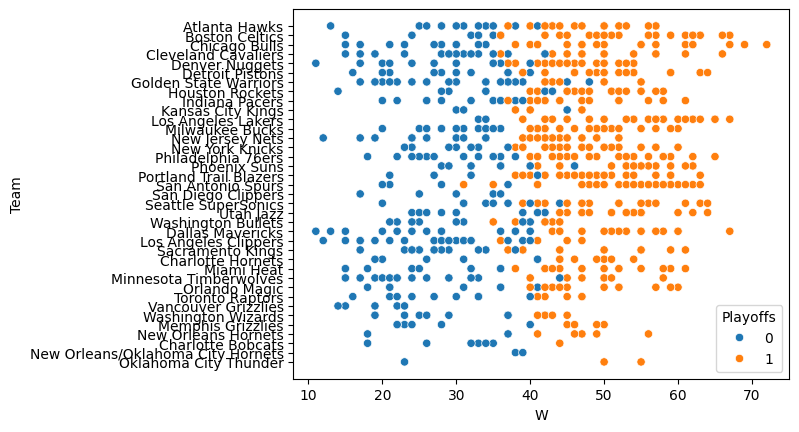

In [72]:
sns.scatterplot(data=df, x='W', y='Team', hue='Playoffs')

#### Take a rough estimate, and now use that moving forward.  



In [26]:
WINS_NEED_TO_MAKE_PLAYOFFS = 40

---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  


```SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2PA: two-pointers attempted
3PA: three-pointers attempted
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers ```

In [57]:
dependent_variable = "PTS"
independent_variables = ["2PA", "3PA", "FTA", 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV']

X = df[independent_variables]
y = df[dependent_variable]

X.head()


,2PA,3PA,FTA,ORB,DRB,AST,STL,BLK,TOV
0,6952,75,2645,1369,2406,1913,782,539,1495
1,6965,422,2449,1227,2457,2198,809,308,1539
2,6668,275,2592,1115,2465,2152,704,392,1684
3,7854,187,2205,1307,2381,2108,764,342,1370
4,7215,255,2539,1311,2524,2079,746,404,1533


In [58]:
X = sm.add_constant(X) 

model = sm.OLS(y, X).fit()

y_pred = model.predict(X)


In [33]:
print(model.summary2())

# get rmse
model_rmse = rmse(y, y_pred)
print("#" * 80)
print("Dependent Variable %s average: " % dependent_variable, y.mean())
print("RMSE:", model_rmse)


                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.898     
Dependent Variable: PTS              AIC:                11102.2409
Date:               2025-10-23 20:39 BIC:                11149.5152
No. Observations:   835              Log-Likelihood:     -5541.1   
Df Model:           9                F-statistic:        817.3     
Df Residuals:       825              Prob (F-statistic): 0.00      
R-squared:          0.899            Scale:              34417.    
-------------------------------------------------------------------
            Coef.    Std.Err.    t     P>|t|    [0.025     0.975]  
-------------------------------------------------------------------
const     -2050.8108 203.4866 -10.0784 0.0000 -2450.2232 -1651.3984
2PA           1.0429   0.0296  35.2738 0.0000     0.9848     1.1009
3PA           1.2586   0.0384  32.7468 0.0000     1.1832     1.3340
FTA           1.1280   0.0337  33.4401 0.0000     1.0618     1.194

In [60]:
independent_variables = ["2PA", "3PA", "FTA"]

X = df[independent_variables]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

y_pred = model.predict(X)

print(model.summary2())

# get rmse
model_rmse = rmse(y, y_pred)
print("#" * 80)
print("Dependent Variable %s average: " % dependent_variable, y.mean())
print("RMSE:", model_rmse)


                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.791     
Dependent Variable: PTS              AIC:                11697.4918
Date:               2025-10-23 22:06 BIC:                11716.4015
No. Observations:   835              Log-Likelihood:     -5844.7   
Df Model:           3                F-statistic:        1050.     
Df Residuals:       831              Prob (F-statistic): 3.63e-282 
R-squared:          0.791            Scale:              70708.    
--------------------------------------------------------------------
          Coef.     Std.Err.     t     P>|t|     [0.025      0.975] 
--------------------------------------------------------------------
const   -1436.9955  230.0320  -6.2469  0.0000  -1888.5076  -985.4834
2PA         1.0415    0.0290  35.9674  0.0000      0.9846     1.0983
3PA         1.2360    0.0464  26.6499  0.0000      1.1449     1.3270
FTA         1.1282    0.0448  25.1661  0.0000      1.0402   

In [61]:
df[independent_variables].corr().round(4)

,2PA,3PA,FTA
2PA,1.0000,-0.9232,0.5238
3PA,-0.9232,1.0000,-0.5378
FTA,0.5238,-0.5378,1.0000


In [64]:
independent_variables = ["2PA", "3PA"]

X = df[independent_variables]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

y_pred = model.predict(X)

print(model.summary2())

# get rmse
model_rmse = rmse(y, y_pred)
print("#" * 80)
print("Dependent Variable %s average: " % dependent_variable, y.mean())
print("RMSE:", model_rmse)


                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.631     
Dependent Variable: PTS              AIC:                12168.5398
Date:               2025-10-23 22:08 BIC:                12182.7221
No. Observations:   835              Log-Likelihood:     -6081.3   
Df Model:           2                F-statistic:        715.3     
Df Residuals:       832              Prob (F-statistic): 1.82e-181 
R-squared:          0.632            Scale:              1.2445e+05
---------------------------------------------------------------------
         Coef.     Std.Err.      t      P>|t|     [0.025      0.975] 
---------------------------------------------------------------------
const   845.7903   280.4445    3.0159   0.0026   295.3283   1396.2522
2PA       1.1028     0.0383   28.8094   0.0000     1.0276      1.1779
3PA       1.0426     0.0607   17.1826   0.0000     0.9235      1.1617
------------------------------------------------------

In [65]:
independent_variables = ["2PA", "FTA"]

X = df[independent_variables]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

y_pred = model.predict(X)

print(model.summary2())

# get rmse
model_rmse = rmse(y, y_pred)
print("#" * 80)
print("Dependent Variable %s average: " % dependent_variable, y.mean())
print("RMSE:", model_rmse)


                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.612     
Dependent Variable: PTS              AIC:                12211.2703
Date:               2025-10-23 22:09 BIC:                12225.4526
No. Observations:   835              Log-Likelihood:     -6102.6   
Df Model:           2                F-statistic:        658.8     
Df Residuals:       832              Prob (F-statistic): 3.21e-172 
R-squared:          0.613            Scale:              1.3098e+05
--------------------------------------------------------------------
            Coef.    Std.Err.     t     P>|t|     [0.025     0.975] 
--------------------------------------------------------------------
const     4235.7086  118.6943  35.6859  0.0000  4002.7331  4468.6841
2PA          0.3521    0.0177  19.8804  0.0000     0.3174     0.3869
FTA          0.9302    0.0602  15.4599  0.0000     0.8121     1.0483
------------------------------------------------------------

In [66]:
independent_variables = ["3PA", "FTA"]

X = df[independent_variables]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

y_pred = model.predict(X)

print(model.summary2())

# get rmse
model_rmse = rmse(y, y_pred)
print("#" * 80)
print("Dependent Variable %s average: " % dependent_variable, y.mean())
print("RMSE:", model_rmse)


                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.465     
Dependent Variable: PTS              AIC:                12479.3357
Date:               2025-10-23 22:10 BIC:                12493.5180
No. Observations:   835              Log-Likelihood:     -6236.7   
Df Model:           2                F-statistic:        363.7     
Df Residuals:       832              Prob (F-statistic): 3.21e-114 
R-squared:          0.466            Scale:              1.8057e+05
--------------------------------------------------------------------
            Coef.    Std.Err.     t     P>|t|     [0.025     0.975] 
--------------------------------------------------------------------
const     5835.5607  175.2771  33.2933  0.0000  5491.5233  6179.5980
3PA         -0.2542    0.0333  -7.6308  0.0000    -0.3195    -0.1888
FTA          1.2638    0.0714  17.7046  0.0000     1.1237     1.4039
------------------------------------------------------------

In [ ]:
X = sm.add_constant(df[["2PA", "3PA", "FTA", 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV']])
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


  feature          VIF
0   const  1004.571127
1     2PA    14.612764
2     3PA     9.827771
3     FTA     1.648202
4     ORB     3.320314
5     DRB     1.568583
6     AST     2.299700
7     STL     1.781731
8     BLK     1.264983
9     TOV     2.150146


In [75]:
X = sm.add_constant(df[["2PA", "3PA", "FTA"]])
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


  feature         VIF
0   const  624.875675
1     2PA    6.822434
2     3PA    6.965348
3     FTA    1.416915


In [76]:
X = sm.add_constant(df[["FTA"]])
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


  feature        VIF
0   const  81.327467
1     FTA   1.000000


In [77]:
independent_variables = ["FTA", "ORB", "DRB", "AST", "STL", "BLK", "TOV"]

X = df[independent_variables]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

y_pred = model.predict(X)

print(model.summary2())

# get rmse
model_rmse = rmse(y, y_pred)
print("#" * 80)
print("Dependent Variable %s average: " % dependent_variable, y.mean())
print("RMSE:", model_rmse)


                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.740     
Dependent Variable: PTS              AIC:                11880.9969
Date:               2025-10-23 22:35 BIC:                11918.8163
No. Observations:   835              Log-Likelihood:     -5932.5   
Df Model:           7                F-statistic:        340.7     
Df Residuals:       827              Prob (F-statistic): 1.14e-238 
R-squared:          0.743            Scale:              87669.    
--------------------------------------------------------------------
            Coef.    Std.Err.     t     P>|t|     [0.025     0.975] 
--------------------------------------------------------------------
const     1727.9357  260.1758   6.6414  0.0000  1217.2530  2238.6183
FTA          0.9292    0.0527  17.6340  0.0000     0.8258     1.0326
ORB          0.6268    0.0909   6.8947  0.0000     0.4484     0.8053
DRB          0.6721    0.0926   7.2546  0.0000     0.4903   

# This is the best predictor so far

In [78]:
X = sm.add_constant(df[["FTA", "ORB", "DRB", "AST", "STL", "BLK", "TOV"]])
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


  feature         VIF
0   const  644.722553
1     FTA    1.578844
2     ORB    1.774347
3     DRB    1.394249
4     AST    1.546713
5     STL    1.680858
6     BLK    1.205978
7     TOV    1.802817


In [92]:
data = df.copy()

# Define the independent and dependent variables
X = data[independent_variables]  # Independent variable
y = data[dependent_variable]  # Dependent variable

# Add a constant to the independent variables (required by statsmodels)
X = sm.add_constant(X)

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build the linear regression model
model = sm.OLS(y_train, X_train).fit()

y_pred = model.predict(X_test)

# Rounding the massive long float
y_pred = round(y_pred, 4)

# Calculate R^2
r_squared = metrics.r2_score(y_test, y_pred)

# Rounding the massive long float
r_squared = round(r_squared, 4)

# Calculate RMSE
model_root_mean_squared_error = rmse(y_test, y_pred)

# Rounding the massive long float
model_root_mean_squared_error = round(model_root_mean_squared_error, 4)

print("R-Squared Score:", r_squared)
print("RMSE:", model_root_mean_squared_error)
print("Dependent Variable %s average: " % dependent_variable, round(y.mean(), 4))
precentage_off = round(model_root_mean_squared_error / y.mean(), 4) * 100
print(f"On average our prediction is %{precentage_off} the dependent variable")




R-Squared Score: 0.6888
RMSE: 334.0644
Dependent Variable PTS average:  8370.2395
On average our prediction is %3.9899999999999998 the dependent variable


In [ ]:
#RSME too high so better to use different variables